# Maximum Bond Dimension for given $g/J$ and System Size
The main function is `generate_plots(g_array, system_sizes)`, which takes in two arrays, one of values of $g$ (where $J$ is fixed at 1) and one of the system sizes that one wants to test. The function then returns the maximum bond dimension required to find the ground state for each system as a matrix of `g_array` vs `system_sizes` and also plots a curve for each value of $g$.

In [1]:
import tenpy
from tenpy.models.tf_ising import TFIChain
from tenpy.networks.mps import MPS
from tenpy.algorithms import dmrg

import matplotlib.pyplot as plt

The function `find_chi_used(g, L, chi_cap, max_sweeps)` returns the maximum bond dimension used to compute the ground state of the TF Ising model for given
- model parameter `g`,
- system size `L`,
- bond dimension cap `chi_cap`, and
- maximum number of sweeps `max_sweeps`.

Note the following fixed parameters:
- algorithm is initialised with a product state (which has zero entanglement, ie $\chi_{\text{max}}=1$) given by $\ket\uparrow^{\otimes L}$
- `J=1.0` so the value of `g` can be interpreted as the ratio $g/J$
- `max_E_err` stops the ground state search when the maximum energy decrease between sweeps is `1e-10`
- `svd_min` truncates singular values below `1e-10`

In [6]:
def find_chi_used(g, L, chi_cap, max_sweeps=10):
    model_params = dict(
        L = L,
        J = 1.0,
        g = g,
        bc_MPS = 'finite',
        conserve = None
    )
    model = TFIChain(model_params)

    product_state = ["up"] * L      # generate initial state. can do ["down"] * L too.
    psi = MPS.from_product_state(
        model.lat.mps_sites(),
        product_state,              # convert product_state to an MPS
        bc='finite',                # open boundary conditions (ie not periodic)
        unit_cell_width=1           # lattice is a 1D chain
    )

    dmrg_params = dict(
        mixer=True,         # adds some controlled randomness to escape bad minima, converge reliably
        max_sweeps=max_sweeps,      # at most 10 back-and-forth passes
        max_E_err=1e-10,    # stop when energy change between sweeps is this small
        trunc_params=dict(  # how to truncate when performing SVD and changing sites
            chi_max=chi_cap,    # maximum allowed bond dimension, ie loosely, maximum allowed entanglement
            svd_min=1e-10   # truncate singular values (diag values in S matrix) below this value
        ),
    )
    
    info = dmrg.run(psi, model, dmrg_params) # run DMRG
    E = info['E']
    return E, max(psi.chi)

`find_chi_required(g, L, tol, max_sweeps)` gradually increments the bond dimension cap `chi_cap` until consecutive ground state energies converge below a tolerance or threshold `tol`.

The bond dimension caps in this implementation start at $\chi=8$ and increase in increments of $1$.

In [7]:
def find_chi_required(g, L, tol=1e-8, max_sweeps=10):
    chi_caps = list(range(8, 80, 4))

    E_prev   = None

    for chi_cap in chi_caps:
        E, chi_used = find_chi_used(g, L, chi_cap, max_sweeps)
        if E_prev is not None:
            if abs(E - E_prev) < tol:
                return chi_used
        E_prev = E
    
    return chi_used

The function `generate_plots(g_array, system_sizes)` takes in two arrays, one of values of `g` (ie the parameter ratio $g/J$) and another of the system sizes to be tested. It then plots all the graphs and of $g/J$ vs $L$ and returns a 2D array / matrix of required bond dimension for a given `g` and `L`.

In [8]:
def generate_plots(g_array, system_sizes):
    chi_grid = []

    for g in g_array:
        row = []
        for L in system_sizes:
            chi_req = find_chi_required(g, L)
            row.append(chi_req)
        
        chi_grid.append(row)
        plt.plot(system_sizes, row, marker='o', markersize=4,label=f"g/J = {g}")

    plt.xlabel("System size L")
    plt.ylabel("Required bond dimension χ")
    plt.legend()
    plt.grid(True)
    plt.show()

    return chi_grid

Now, we can input the parameter ratios $g/J$ and the system sizes that we want tested:

final DMRG state not in canonical form up to norm_tol=1.00e-05: norm_err=1.14e-05
final DMRG state not in canonical form up to norm_tol=1.00e-05: norm_err=1.51e-05
final DMRG state not in canonical form up to norm_tol=1.00e-05: norm_err=1.92e-05


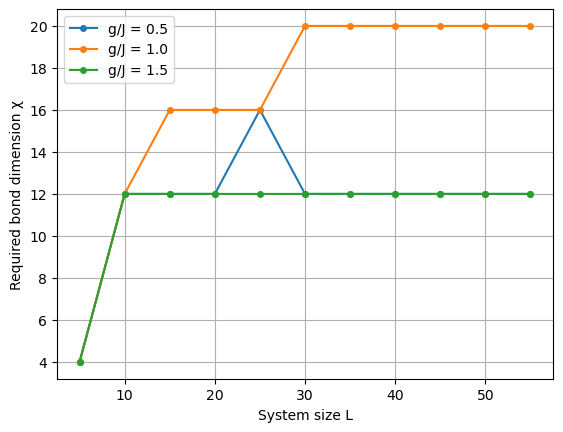

[[4, 12, 12, 12, 16, 12, 12, 12, 12, 12, 12],
 [4, 12, 16, 16, 16, 20, 20, 20, 20, 20, 20],
 [4, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12]]

In [9]:
system_sizes = list(range(5, 60, 5))
g_array = [0.5, 1.0, 1.5]

generate_plots(g_array, system_sizes)